# Imported Inflation Analysis in Mauritania

This notebook analyses imported inflation in Mauritania using the National Consumer Price Index (INPC), the import Unit Value Index (UVI), the USD/MRU exchange rate and detailed Level 2 import categories. The methodology and numerical results are preserved exactly from the original graduation project.

## 1. Environment and libraries

Import the libraries used for data processing, econometrics, machine learning and visualisation.

In [1]:
# %% Cell 0
# ============================================================
# 0. Projet complet : INPC + IVU + taux de change + DLM score + ARIMAX/SARIMAX + ML
# ============================================================

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:,.6f}".format)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

print("Libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


## 2. Project paths and parameters

Define private input files, public output folders and the original methodological parameters. Institutional data are expected locally in `data/private/` and are not published.

In [2]:
# Project-relative paths and original parameters
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "data").exists() else CURRENT_DIR.parent
PRIVATE_DATA_DIR = PROJECT_ROOT / "data" / "private"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

def trouver_fichier(nom_fichier, dossiers=(PRIVATE_DATA_DIR,)):
    for dossier in dossiers:
        chemin = dossier / nom_fichier
        if chemin.exists():
            return chemin
    return None

nom_inpc = "Historique_INPC_base_2019_Etude inflation-2025.xlsx"
nom_ivu = "IndiceMensuel base 100=2024.xlsx"
nom_taux_change = "coellecte taux_de_change_Najeeb.xlsx"
nom_import_1 = "data (21).xlsx"
nom_import_2 = "data (22).xlsx"

fichier_inpc = trouver_fichier(nom_inpc)
fichier_ivu = trouver_fichier(nom_ivu)
fichier_taux_change = trouver_fichier(nom_taux_change)
fichier_import_1 = trouver_fichier(nom_import_1)
fichier_import_2 = trouver_fichier(nom_import_2)

fichiers = {"INPC": fichier_inpc, "UVI": fichier_ivu, "Exchange rate": fichier_taux_change, "Import file 1": fichier_import_1, "Import file 2": fichier_import_2}
for nom, chemin in fichiers.items():
    print(f"{nom:16s} =>", "OK" if chemin else "MISSING")
manquants = [nom for nom, chemin in fichiers.items() if chemin is None]
if manquants:
    raise FileNotFoundError("Missing private institutional files: " + ", ".join(manquants) + "\nPlace them locally in data/private/. They are intentionally excluded from GitHub.")

COL_NIVEAU2 = "Niveau2"
K_RETARDS_DLM = 6
K_RETARDS_MACRO = 3
MIN_MOIS_DISPONIBLES = 36
MIN_VARIATIONS_VALIDES = 36
MIN_OBS_MODELE = 36
SEUIL_SIGNIF = 0.10
MAX_RANG_IMPORTANCE = 30
DATE_DEBUT_TEST = pd.Timestamp("2025-01-01")
TOP_N_FINAL = 10
METRIQUE_SELECTION = "RMSE_inflation"
DOSSIER_OUTPUTS = FIGURES_DIR
print("Original project parameters loaded.")

INPC             => OK
UVI              => OK
Exchange rate    => OK
Import file 1    => OK
Import file 2    => OK
Original project parameters loaded.


## 3. Utility functions

Define the original date-conversion, evaluation and INPC-reconstruction functions.

In [3]:
# %% Cell 2
# ============================================================
# 2. Fonctions utilitaires
# ============================================================

def parse_colonne_mensuelle(col):
    """Convertit une colonne du type 2020M1 en Timestamp 2020-01-01."""
    col = str(col).strip()
    match = re.match(r"^(\d{4})M(\d{1,2})$", col)
    if match:
        annee = int(match.group(1))
        mois = int(match.group(2))
        return pd.Timestamp(year=annee, month=mois, day=1)
    return None


def convertir_dates_excel_ou_standard(serie):
    """Convertit une série pouvant contenir des dates Excel numériques ou des dates standards."""
    dates = pd.to_datetime(serie, errors="coerce")
    nums = pd.to_numeric(serie, errors="coerce")
    mask = dates.isna() & nums.notna()
    if mask.any():
        dates.loc[mask] = pd.to_datetime(nums.loc[mask], unit="D", origin="1899-12-30", errors="coerce")
    return dates


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def reconstruire_inpc(inpc_depart, inflation_predite):
    valeurs = []
    dernier_inpc = float(inpc_depart)
    for infl in inflation_predite:
        nouveau_inpc = dernier_inpc * np.exp(float(infl) / 100)
        valeurs.append(nouveau_inpc)
        dernier_inpc = nouveau_inpc
    return np.array(valeurs)


def r2_correlation(y_true, y_pred):
    """R2 non négatif pour la soutenance : R2 = corr(y réel, y prédit)^2."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 2:
        return np.nan
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return 0.0
    return float(np.corrcoef(y_true, y_pred)[0, 1] ** 2)


def calculer_metrics(y_test, y_pred, inpc_reel, inpc_pred):
    """Calcule les indicateurs de performance pour inflation et INPC reconstruit."""
    y_test = np.asarray(y_test, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    inpc_reel = np.asarray(inpc_reel, dtype=float)
    inpc_pred = np.asarray(inpc_pred, dtype=float)

    mae_inflation = mean_absolute_error(y_test, y_pred)
    rmse_inflation = rmse(y_test, y_pred)
    mape_inflation = mape(y_test, y_pred)
    r2_inflation = r2_correlation(y_test, y_pred)

    mae_inpc = mean_absolute_error(inpc_reel, inpc_pred)
    rmse_inpc = rmse(inpc_reel, inpc_pred)
    mape_inpc = mape(inpc_reel, inpc_pred)
    accuracy_inpc = 100 - mape_inpc if pd.notna(mape_inpc) else np.nan
    r2_inpc = r2_correlation(inpc_reel, inpc_pred)

    return {
        "MAE_inflation": mae_inflation,
        "RMSE_inflation": rmse_inflation,
        "MAPE_inflation_%": mape_inflation,
        "R2_inflation": r2_inflation,
        "MAE_INPC": mae_inpc,
        "RMSE_INPC": rmse_inpc,
        "MAPE_INPC_%": mape_inpc,
        "Accuracy_INPC_%": accuracy_inpc,
        "R2_INPC": r2_inpc,
    }

def afficher_et_sauver(df, nom):
    display(public_table(df))
    chemin = TABLES_DIR / f"{nom}.csv"
    public_table(df).to_csv(chemin, index=False, encoding="utf-8-sig")
    print("Saved:", chemin)

print("Utility functions ready.")

PUBLIC_COLUMN_NAMES = {'Niveau2': 'Level 2 category', 'rang_score_economique': 'Economic score rank', 'score_economique': 'Economic score', 'score_economique_x1000': 'Economic score × 1,000', 'beta_0': 'Immediate effect (β0)', 'beta_cumule': 'Cumulative effect (β)', 'part_valeur_import': 'Import value share', 'part_valeur_import_%': 'Import value share (%)', 'meilleur_lag': 'Main lag (months)', 'p_value_test_conjoint': 'Joint-test p-value', 'r2_ajuste': 'Adjusted R²', 'modele': 'Model', 'famille': 'Model family', 'nb_train': 'Training observations', 'nb_test': 'Test observations', 'MAPE_%': 'MAPE (%)'}
MODEL_LABELS_EN = {'ARIMAX_IVU_TAUX': 'ARIMAX', 'SARIMAX_IVU_TAUX': 'SARIMAX', 'Gradient_Boosting_IVU_TAUX': 'Gradient Boosting', 'Random_Forest_IVU_TAUX': 'Random Forest', 'Elastic_Net_IVU_TAUX': 'Elastic Net', 'Ridge_IVU_TAUX': 'Ridge', 'Lasso_IVU_TAUX': 'Lasso'}

def translate_level2_label(value):
    text = str(value)
    mapping = {
        "Combustibles minéraux": "Mineral fuels, lubricants and related materials",
        "Céréales non transformées": "Unprocessed cereals",
        "Produits pétroliers raffinés": "Refined petroleum products",
        "Huiles et graisses animale": "Animal oils and fats",
        "Viandes et ses préparations": "Meat and meat preparations",
        "Produits chimiques organiques": "Organic chemicals",
        "Laits et produits laitiers": "Milk and dairy products",
        "Fer, fonte et acier": "Iron, cast iron and steel",
        "Sucre et sucrerie": "Sugar and confectionery",
        "Matières et ouvrages plastiques": "Plastics and plastic products",
    }
    for prefix, translated in mapping.items():
        if text.startswith(prefix):
            return translated
    return text

def public_table(df):
    result = df.copy()
    if "Niveau2" in result.columns:
        result["Niveau2"] = result["Niveau2"].map(translate_level2_label)
    if "modele" in result.columns:
        result["modele"] = result["modele"].replace(MODEL_LABELS_EN)
    if "famille" in result.columns:
        result["famille"] = result["famille"].replace({"Statistique": "Statistical", "Machine Learning": "Machine Learning"})
    return result.rename(columns=PUBLIC_COLUMN_NAMES)


Utility functions ready.


## 4. National Consumer Price Index (INPC)

Load and prepare the national monthly INPC series and compute monthly inflation.

In [4]:
# %% Cell 3
# ============================================================
# 3. Lecture et préparation de l'INPC global
# ============================================================

inpc_raw = pd.read_excel(fichier_inpc, sheet_name="Indices-INPC", header=1)
inpc_raw.columns = [c.strip() if isinstance(c, str) else c for c in inpc_raw.columns]

ligne_inpc = inpc_raw[inpc_raw["CODE"].astype(str).str.strip() == "INDICE GLOBAL"]
if len(ligne_inpc) != 1:
    raise ValueError("La ligne CODE = INDICE GLOBAL n'est pas unique ou n'existe pas.")
ligne_inpc = ligne_inpc.iloc[0]

colonnes_dates_inpc = []
for col in inpc_raw.columns:
    date_test = pd.to_datetime(col, errors="coerce")
    if not pd.isna(date_test):
        colonnes_dates_inpc.append(col)

inpc = ligne_inpc[colonnes_dates_inpc].reset_index()
inpc.columns = ["date", "INPC_global"]
inpc["date"] = pd.to_datetime(inpc["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
inpc["INPC_global"] = pd.to_numeric(inpc["INPC_global"], errors="coerce")
inpc = inpc.dropna(subset=["date", "INPC_global"]).sort_values("date").reset_index(drop=True)
inpc["inflation_mensuelle"] = 100 * (np.log(inpc["INPC_global"]) - np.log(inpc["INPC_global"].shift(1)))

print("INPC prepared")
print("INPC period:", inpc["date"].min(), "to", inpc["date"].max())
print("Number of INPC observations:", len(inpc))

INPC prepared
INPC period: 2019-01-01 00:00:00 to 2025-12-01 00:00:00
Number of INPC observations: 84


## 5. Import Unit Value Index (UVI)

Load and prepare the monthly UVI series and its logarithmic variation.

In [5]:
# %% Cell 4
# ============================================================
# 4. Lecture et préparation de l'IVU global
# ============================================================

ivu_raw = pd.read_excel(fichier_ivu, sheet_name="Feuille1", header=1)
ivu_raw.columns = [str(c).strip() if not pd.isna(c) else f"col_{i}" for i, c in enumerate(ivu_raw.columns)]

colonnes_dates_ivu = [col for col in ivu_raw.columns if parse_colonne_mensuelle(col) is not None]
if len(colonnes_dates_ivu) == 0:
    raise ValueError("Aucune colonne mensuelle IVU de type 2020M1 n'a été détectée.")

col_code_ivu = ivu_raw.columns[0]
col_label_ivu = "SHPay"

ligne_ivu = ivu_raw[ivu_raw[col_label_ivu].astype(str).str.strip().str.lower() == "total"]
if len(ligne_ivu) == 0:
    ligne_ivu = ivu_raw[ivu_raw[col_code_ivu].astype(str).str.strip().str.upper() == "SH06"]
if len(ligne_ivu) != 1:
    raise ValueError("La ligne IVU globale Total / SH06 n'est pas unique ou n'existe pas.")
ligne_ivu = ligne_ivu.iloc[0]

ivu = ligne_ivu[colonnes_dates_ivu].reset_index()
ivu.columns = ["periode", "IVU_global"]
ivu["date"] = ivu["periode"].apply(parse_colonne_mensuelle)
ivu["IVU_global"] = pd.to_numeric(ivu["IVU_global"], errors="coerce")
ivu = ivu.dropna(subset=["date", "IVU_global"])[["date", "IVU_global"]].sort_values("date").reset_index(drop=True)
ivu["variation_ivu"] = 100 * (np.log(ivu["IVU_global"]) - np.log(ivu["IVU_global"].shift(1)))

print("UVI prepared")
print("UVI period:", ivu["date"].min(), "to", ivu["date"].max())
print("Number of UVI observations:", len(ivu))

UVI prepared
UVI period: 2020-01-01 00:00:00 to 2025-09-01 00:00:00
Number of UVI observations: 69


## 6. USD/MRU exchange rate

Load and aggregate the exchange-rate series at monthly frequency.

In [6]:
# %% Cell 5
# ============================================================
# 5. Lecture et préparation du taux de change USD/MRU
# ============================================================

taux_raw = pd.read_excel(fichier_taux_change, sheet_name="Saisie_Changes", header=None)

# Ligne Excel 329 => index Python 328 ; colonnes L:M => indices 11 et 12
zone_taux = taux_raw.iloc[328:, [11, 12]].copy()
zone_taux.columns = ["date", "taux_usd_mru"]

zone_taux["date"] = convertir_dates_excel_ou_standard(zone_taux["date"])
zone_taux["taux_usd_mru"] = pd.to_numeric(zone_taux["taux_usd_mru"], errors="coerce")

# Sécurité : si la zone L:M est vide dans une autre version du fichier, essayer A:B
if zone_taux.dropna(subset=["date", "taux_usd_mru"]).empty:
    print("Attention : la zone L:M est vide. Tentative de lecture A:B.")
    zone_taux = taux_raw.iloc[328:, [0, 1]].copy()
    zone_taux.columns = ["date", "taux_usd_mru"]
    zone_taux["date"] = convertir_dates_excel_ou_standard(zone_taux["date"])
    zone_taux["taux_usd_mru"] = pd.to_numeric(zone_taux["taux_usd_mru"], errors="coerce")

zone_taux = zone_taux.dropna(subset=["date", "taux_usd_mru"]).copy()
zone_taux["date"] = zone_taux["date"].dt.to_period("M").dt.to_timestamp()

# Si plusieurs valeurs dans un même mois, on prend la moyenne mensuelle
taux_mensuel = (
    zone_taux.groupby("date", as_index=False)["taux_usd_mru"]
    .mean()
    .sort_values("date")
    .reset_index(drop=True)
)

taux_mensuel["variation_taux_change"] = 100 * (
    np.log(taux_mensuel["taux_usd_mru"]) - np.log(taux_mensuel["taux_usd_mru"].shift(1))
)

print("Exchange rate prepared")
print("Exchange-rate period:", taux_mensuel["date"].min(), "to", taux_mensuel["date"].max())
print("Number of exchange-rate observations:", len(taux_mensuel))

Exchange rate prepared
Exchange-rate period: 2020-01-01 00:00:00 to 2025-09-01 00:00:00
Number of exchange-rate observations: 69


## 7. Common macroeconomic dataset

Merge INPC, UVI and exchange-rate data and create the original lagged variables.

In [7]:
# %% Cell 6
# ============================================================
# 6. Base macro commune INPC-IVU-taux
# ============================================================

base_macro = (
    inpc[["date", "INPC_global", "inflation_mensuelle"]]
    .merge(ivu[["date", "IVU_global", "variation_ivu"]], on="date", how="inner")
    .merge(taux_mensuel[["date", "taux_usd_mru", "variation_taux_change"]], on="date", how="inner")
    .sort_values("date")
    .reset_index(drop=True)
)

print("Common macroeconomic period:", base_macro["date"].min(), "to", base_macro["date"].max())
print("Number of common observations:", len(base_macro))

base_macro["inflation_lag1"] = base_macro["inflation_mensuelle"].shift(1)
base_macro["inflation_lag12"] = base_macro["inflation_mensuelle"].shift(12)

features_macro = []
for lag in range(K_RETARDS_MACRO + 1):
    col_ivu = f"variation_ivu_lag{lag}"
    col_taux = f"variation_taux_change_lag{lag}"
    base_macro[col_ivu] = base_macro["variation_ivu"].shift(lag)
    base_macro[col_taux] = base_macro["variation_taux_change"].shift(lag)
    features_macro.extend([col_ivu, col_taux])

base_macro_model = base_macro.dropna(subset=["INPC_global", "inflation_mensuelle"] + features_macro).copy()

print("Macroeconomic dataset after lag creation:", base_macro_model.shape)
print("Macroeconomic features:", features_macro)

Common macroeconomic period: 2020-01-01 00:00:00 to 2025-09-01 00:00:00
Number of common observations: 69
Macroeconomic dataset after lag creation: (65, 17)
Macroeconomic features: ['variation_ivu_lag0', 'variation_taux_change_lag0', 'variation_ivu_lag1', 'variation_taux_change_lag1', 'variation_ivu_lag2', 'variation_taux_change_lag2', 'variation_ivu_lag3', 'variation_taux_change_lag3']


## 8. Detailed import data preparation

Prepare Level 2 import records for the distributed lag analysis without displaying raw institutional rows.

In [8]:
# %% Cell 7
# ============================================================
# 7. Préparation des importations pour DLM Niveau2
# ============================================================

date_debut_commune = max(inpc["date"].min(), ivu["date"].min())
date_fin_commune = min(inpc["date"].max(), ivu["date"].max())

print("Common period used for Level 2 categories:", date_debut_commune, "to", date_fin_commune)

# Lecture optimisée : on ne charge que les colonnes nécessaires pour le DLM.
# Si des fichiers cache CSV existent, on les utilise pour accélérer l'exécution.
colonnes_imports_utiles = [
    "DateLiquid1 - Année", "PERIOD", COL_NIVEAU2,
    "VALEUR", "POIDSNET", "Type", "TYYPE"
]

cache_import_1 = PRIVATE_DATA_DIR / "test_cache21.csv"
cache_import_2 = PRIVATE_DATA_DIR / "_cache_import_2.csv"

if cache_import_1.exists() and cache_import_2.exists():
    print("Fast loading from local CSV cache.")
    df1 = pd.read_csv(cache_import_1, usecols=lambda c: str(c).strip() in colonnes_imports_utiles)
    df2 = pd.read_csv(cache_import_2, usecols=lambda c: str(c).strip() in colonnes_imports_utiles)
else:
    print("Loading from private Excel files. This step may take a few minutes.")
    df1 = pd.read_excel(fichier_import_1, sheet_name="Export", usecols=lambda c: str(c).strip() in colonnes_imports_utiles)
    df2 = pd.read_excel(fichier_import_2, sheet_name="Export", usecols=lambda c: str(c).strip() in colonnes_imports_utiles)

imports = pd.concat([df1, df2], ignore_index=True)
imports.columns = imports.columns.astype(str).str.strip()

pattern_technique = r"^\s*total\s*$|applied filters|grand total"
mask_lignes_techniques = imports.astype(str).apply(
    lambda col: col.str.contains(pattern_technique, case=False, na=False, regex=True)
).any(axis=1)
imports = imports.loc[~mask_lignes_techniques].copy()

imports_clean = imports.copy()
imports_clean["annee"] = pd.to_numeric(imports_clean["DateLiquid1 - Année"], errors="coerce")
imports_clean["mois"] = pd.to_numeric(imports_clean["PERIOD"], errors="coerce")
imports_clean["VALEUR"] = pd.to_numeric(imports_clean["VALEUR"], errors="coerce")
imports_clean["POIDSNET"] = pd.to_numeric(imports_clean["POIDSNET"], errors="coerce")
imports_clean[COL_NIVEAU2] = imports_clean[COL_NIVEAU2].astype(str).str.strip()

imports_clean = imports_clean.dropna(subset=["annee", "mois"]).copy()
imports_clean["date"] = pd.to_datetime(
    imports_clean["annee"].astype(int).astype(str) + "-" +
    imports_clean["mois"].astype(int).astype(str).str.zfill(2) + "-01"
)
imports_clean["date"] = imports_clean["date"].dt.to_period("M").dt.to_timestamp()
imports_clean["periode"] = imports_clean["date"].dt.to_period("M").astype(str)

imports_clean = imports_clean[
    (imports_clean["date"] >= date_debut_commune) &
    (imports_clean["date"] <= date_fin_commune)
].copy()

imports_clean = imports_clean[
    (imports_clean["Type"].astype(str).str.strip().str.lower() == "importation") |
    (imports_clean["TYYPE"].astype(str).str.strip().str.upper() == "I")
].copy()

imports_clean = imports_clean.dropna(subset=[COL_NIVEAU2, "VALEUR", "POIDSNET"]).copy()
imports_clean = imports_clean[(imports_clean["VALEUR"] > 0) & (imports_clean["POIDSNET"] > 0)].copy()
imports_clean = imports_clean[~imports_clean[COL_NIVEAU2].str.lower().isin(["", "nan", "none", "total", "grand total"])].copy()

print("Clean import dataset shape:", imports_clean.shape)
print("Clean import dataset period:", imports_clean["date"].min(), "to", imports_clean["date"].max())
print("Number of Level 2 categories:", imports_clean[COL_NIVEAU2].nunique())

Common period used for Level 2 categories: 2020-01-01 00:00:00 to 2025-09-01 00:00:00
Loading from private Excel files. This step may take a few minutes.
Clean import dataset shape: (164737, 11)
Clean import dataset period: 2020-01-01 00:00:00 to 2025-09-01 00:00:00
Number of Level 2 categories: 124


## 9. Monthly aggregation by Level 2 category

Aggregate import value and net weight, compute unit prices and prepare the DLM input matrix.

In [9]:
# %% Cell 8
# ============================================================
# 8. Agrégation mensuelle Niveau2 et DLM
# ============================================================

inpc_commune = inpc[(inpc["date"] >= date_debut_commune) & (inpc["date"] <= date_fin_commune)].copy()

agg_niveau2 = (
    imports_clean
    .groupby(["date", "periode", COL_NIVEAU2], as_index=False)
    .agg(
        somme_valeur=("VALEUR", "sum"),
        somme_poidsnet=("POIDSNET", "sum"),
        nb_lignes=("VALEUR", "size")
    )
)
agg_niveau2["prix_unitaire"] = agg_niveau2["somme_valeur"] / agg_niveau2["somme_poidsnet"]

obs_par_niveau2 = agg_niveau2.groupby(COL_NIVEAU2)["periode"].nunique().sort_values(ascending=False)
niveau2_valides = obs_par_niveau2[obs_par_niveau2 >= MIN_MOIS_DISPONIBLES].index.tolist()
agg_niveau2_filtre = agg_niveau2[agg_niveau2[COL_NIVEAU2].isin(niveau2_valides)].copy()

prix_wide = agg_niveau2_filtre.pivot(index="date", columns=COL_NIVEAU2, values="prix_unitaire").sort_index()
inpc_ts = inpc_commune.set_index("date").sort_index()
base_model = inpc_ts.join(prix_wide, how="inner")

colonnes_niveau2 = [col for col in base_model.columns if col not in ["INPC_global", "inflation_mensuelle"]]
prix_import = base_model[colonnes_niveau2].copy()

# Winsorisation pour limiter l'effet des valeurs extrêmes
prix_import_winsor = prix_import.copy()
for col in prix_import_winsor.columns:
    q01 = prix_import_winsor[col].quantile(0.01)
    q99 = prix_import_winsor[col].quantile(0.99)
    prix_import_winsor[col] = prix_import_winsor[col].clip(lower=q01, upper=q99)

x_variations = 100 * (np.log(prix_import_winsor) - np.log(prix_import_winsor.shift(1)))
data_dlm = pd.concat([base_model[["INPC_global", "inflation_mensuelle"]], x_variations], axis=1)
obs_x_valides = x_variations.notna().sum()
categories_a_tester = obs_x_valides[obs_x_valides >= MIN_VARIATIONS_VALIDES].index.tolist()

# poids des importations
poids_import = (
    imports_clean.groupby(COL_NIVEAU2, as_index=False)["VALEUR"].sum()
    .rename(columns={"VALEUR": "valeur_import"})
)
poids_import["part_valeur_import"] = poids_import["valeur_import"] / poids_import["valeur_import"].sum()
poids_import = poids_import.sort_values("part_valeur_import", ascending=False).reset_index(drop=True)
poids_import["rang_importance"] = np.arange(1, len(poids_import) + 1)

print("Number of categories to test:", len(categories_a_tester))
print("DLM dataset shape:", data_dlm.shape)

Number of categories to test: 91
DLM dataset shape: (69, 100)


## 10. Distributed Lag Models and economic score

Estimate one DLM per eligible category and rank selected categories using the original economic-score formula.

In [10]:
# %% Cell 9
# ============================================================
# 9. Estimation DLM par Niveau2 et classement score économique
# ============================================================

def estimer_dlm_une_categorie(data, categorie, k=6):
    df = pd.DataFrame(index=data.index)
    df["y"] = data["inflation_mensuelle"]
    df["x"] = data[categorie]
    df["y_lag1"] = df["y"].shift(1)

    variables_x_lags = []
    for lag in range(k + 1):
        nom_col = f"x_lag{lag}"
        df[nom_col] = df["x"].shift(lag)
        variables_x_lags.append(nom_col)

    df_model = df.dropna().copy()
    if len(df_model) < 20:
        return None, None

    y = df_model["y"]
    X = sm.add_constant(df_model[["y_lag1"] + variables_x_lags])
    modele = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": k})
    betas = modele.params[variables_x_lags]

    beta_0 = betas["x_lag0"]
    beta_cumule = betas.sum()
    meilleur_lag = int(betas.abs().idxmax().replace("x_lag", ""))

    noms_params = list(modele.params.index)
    R = np.zeros((len(variables_x_lags), len(modele.params)))
    for i, var in enumerate(variables_x_lags):
        R[i, noms_params.index(var)] = 1
    test_conjoint = modele.wald_test(R, scalar=True)

    resume = {
        COL_NIVEAU2: categorie,
        "k": k,
        "nb_observations": len(df_model),
        "beta_0": beta_0,
        "beta_cumule": beta_cumule,
        "meilleur_lag": meilleur_lag,
        "p_value_test_conjoint": float(test_conjoint.pvalue),
        "r2_ajuste": modele.rsquared_adj,
    }
    return modele, resume

resultats_dlm = []
erreurs = []

for categorie in categories_a_tester:
    try:
        modele, resume = estimer_dlm_une_categorie(data_dlm, categorie, k=K_RETARDS_DLM)
        if resume is not None:
            resultats_dlm.append(resume)
        else:
            erreurs.append((categorie, "Pas assez d'observations après dropna"))
    except Exception as e:
        erreurs.append((categorie, str(e)))

resultats_dlm = pd.DataFrame(resultats_dlm)
resultats_dlm = resultats_dlm.merge(poids_import, on=COL_NIVEAU2, how="left")
resultats_dlm["score_economique"] = resultats_dlm["beta_cumule"] * resultats_dlm["part_valeur_import"]

conditions_selection = (
    (resultats_dlm["rang_importance"] <= MAX_RANG_IMPORTANCE) &
    (resultats_dlm["nb_observations"] >= MIN_OBS_MODELE) &
    (resultats_dlm["beta_cumule"] > 0) &
    (resultats_dlm["p_value_test_conjoint"] <= SEUIL_SIGNIF)
)
resultats_dlm["statut_selection"] = np.where(conditions_selection, "selectionnee", "non_selectionnee")

classement_score = (
    resultats_dlm[resultats_dlm["statut_selection"] == "selectionnee"]
    .sort_values("score_economique", ascending=False)
    .reset_index(drop=True)
)
classement_score["rang_score_economique"] = np.arange(1, len(classement_score) + 1)
top10_score = classement_score.head(TOP_N_FINAL).copy()

print("Number of estimated DLM models:", len(resultats_dlm))
print("Number of estimation errors:", len(erreurs))
print("Number of selected categories:", len(classement_score))
afficher_et_sauver(top10_score, "top10_level2_economic_score")

Number of estimated DLM models: 85
Number of estimation errors: 6
Number of selected categories: 14


,Level 2 category,k,nb_observations,Immediate effect (β0),Cumulative effect (β),Main lag (months),Joint-test p-value,Adjusted R²,valeur_import,Import value share,rang_importance,Economic score,statut_selection,Economic score rank
0,"Mineral fuels, lubricants and related materials",6,62,0.007508,0.034782,4,0.040111,0.315758,"278,153,877,201.780029",0.297296,1,0.010340,selectionnee,1
1,Unprocessed cereals,6,62,0.008595,0.029467,0,0.063047,0.227459,"58,708,490,191.335999",0.062749,2,0.001849,selectionnee,2
2,Refined petroleum products,6,62,-0.003341,0.015417,4,0.021347,0.231230,"36,343,159,584.702003",0.038844,8,0.000599,selectionnee,3
3,Animal oils and fats,6,62,0.004595,0.009208,5,0.000677,0.175963,"48,469,730,611.383003",0.051805,5,0.000477,selectionnee,4
4,Meat and meat preparations,6,62,-0.008565,0.041163,5,0.009639,0.208774,"8,213,337,781.184000",0.008779,21,0.000361,selectionnee,5
5,Organic chemicals,6,62,0.000155,0.016879,4,0.020197,0.305761,"14,561,924,690.841000",0.015564,15,0.000263,selectionnee,6
6,Milk and dairy products,6,62,-0.006737,0.012916,5,0.005236,0.272604,"18,036,473,991.470001",0.019278,13,0.000249,selectionnee,7
7,"Iron, cast iron and steel",6,62,0.000940,0.020664,1,0.000046,0.275492,"10,872,693,940.664000",0.011621,17,0.000240,selectionnee,8
8,Sugar and confectionery,6,62,0.002266,0.003772,3,0.000122,0.227788,"55,490,749,204.398003",0.059310,4,0.000224,selectionnee,9
9,Plastics and plastic products,6,62,0.006961,0.026521,0,0.041849,0.179992,"6,314,307,160.114000",0.006749,25,0.000179,selectionnee,10


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\tables\top10_level2_economic_score.csv


## 11. Top 10 imported categories

Present the original Top 10 ranking and its economic interpretation through summary charts.

Top 10 Niveau2 conservé comme résultat DLM descriptif, classé selon score_economique.
Ce Top10 n'est pas utilisé dans les modèles ML macro pour éviter le sur-ajustement.


,Level 2 category,Economic score rank,Economic score,"Economic score × 1,000",Immediate effect (β0),Cumulative effect (β),Import value share,Import value share (%),Main lag (months),Joint-test p-value,Adjusted R²
0,"Mineral fuels, lubricants and related materials",1,0.010340,10.340466,0.007508,0.034782,0.297296,29.729626,4,0.040111,0.315758
1,Unprocessed cereals,2,0.001849,1.849044,0.008595,0.029467,0.062749,6.274877,0,0.063047,0.227459
2,Refined petroleum products,3,0.000599,0.598863,-0.003341,0.015417,0.038844,3.884427,4,0.021347,0.231230
3,Animal oils and fats,4,0.000477,0.477049,0.004595,0.009208,0.051805,5.180539,5,0.000677,0.175963
4,Meat and meat preparations,5,0.000361,0.361352,-0.008565,0.041163,0.008779,0.877857,5,0.009639,0.208774
5,Organic chemicals,6,0.000263,0.262702,0.000155,0.016879,0.015564,1.556407,4,0.020197,0.305761
6,Milk and dairy products,7,0.000249,0.248992,-0.006737,0.012916,0.019278,1.927773,5,0.005236,0.272604
7,"Iron, cast iron and steel",8,0.000240,0.240139,0.000940,0.020664,0.011621,1.162095,1,0.000046,0.275492
8,Sugar and confectionery,9,0.000224,0.223743,0.002266,0.003772,0.059310,5.930959,3,0.000122,0.227788
9,Plastics and plastic products,10,0.000179,0.178988,0.006961,0.026521,0.006749,0.674885,0,0.041849,0.179992


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\tables\top10_imported_categories.csv


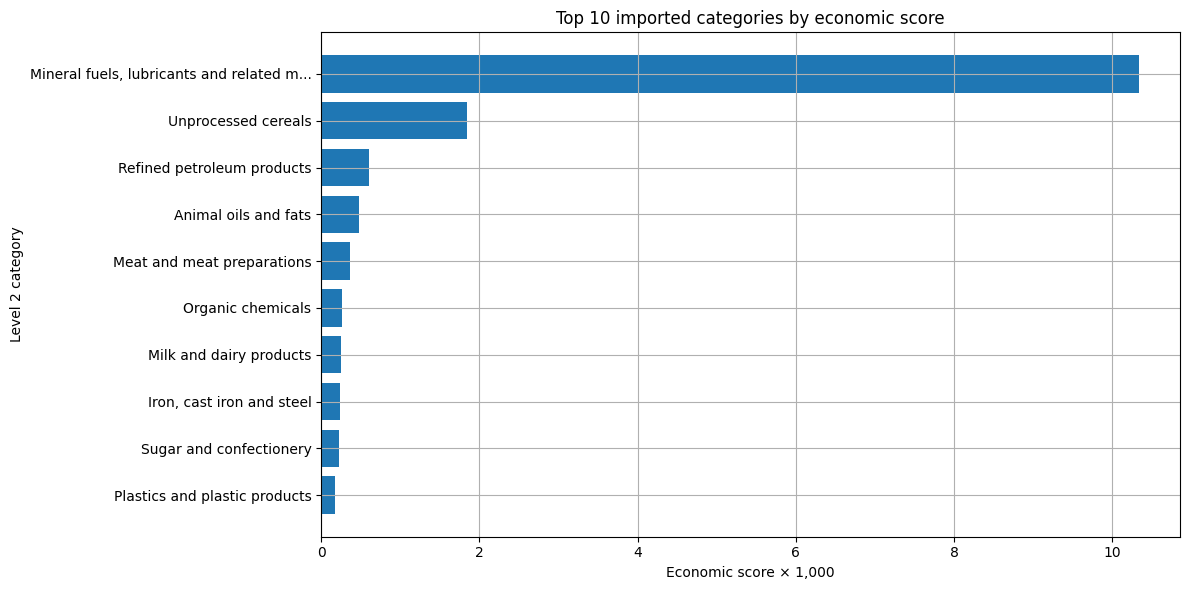

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\figures\top10_economic_score.png


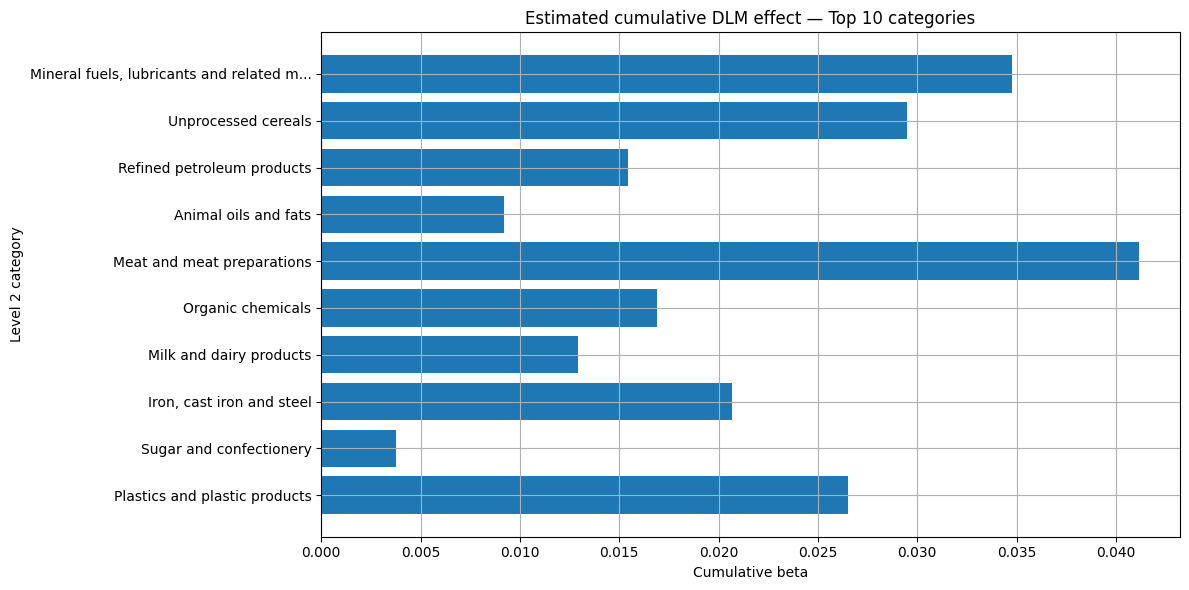

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\figures\top10_cumulative_effect.png


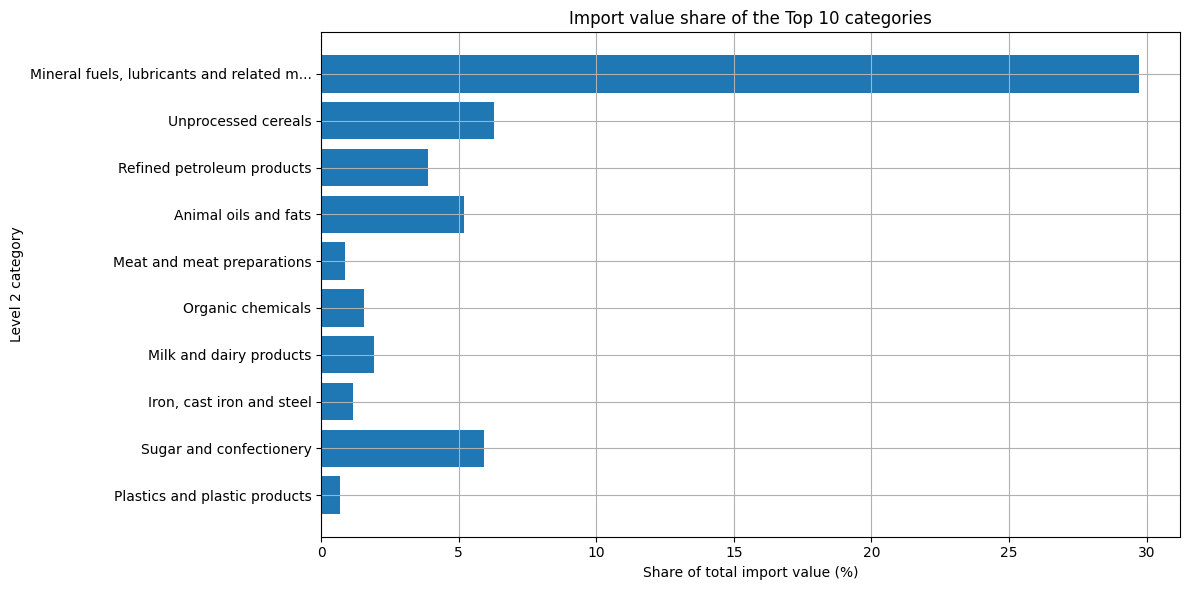

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\figures\top10_import_share.png


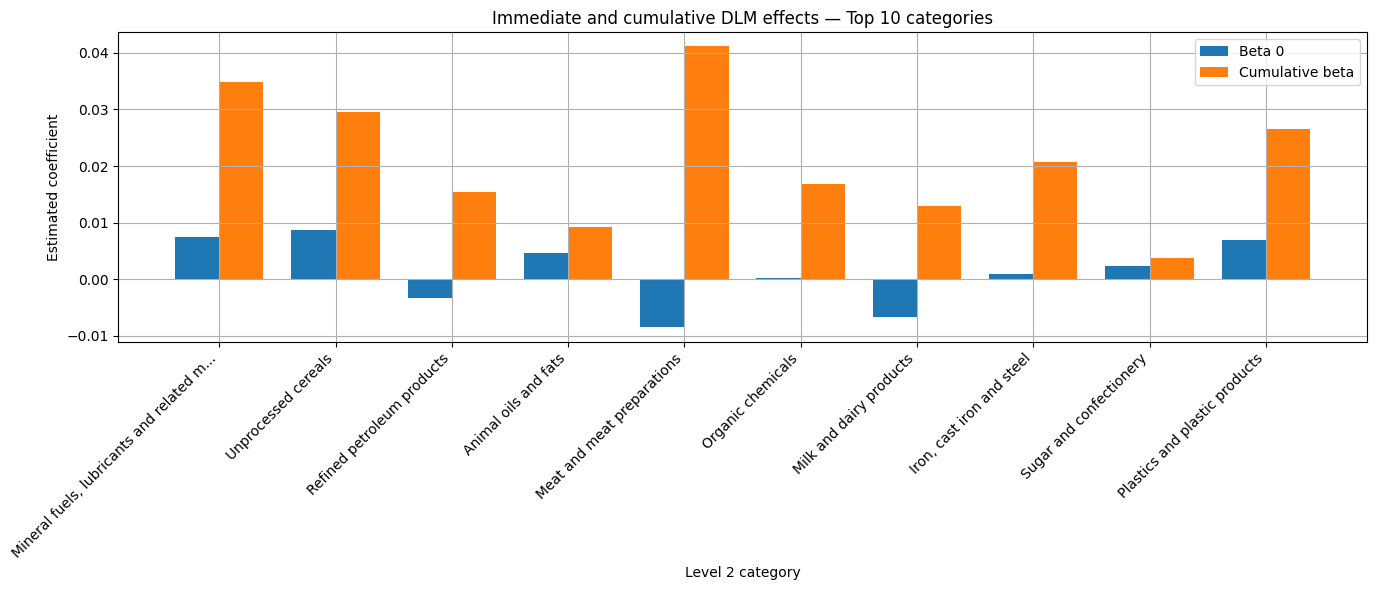

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\figures\top10_immediate_vs_cumulative_effect.png


In [11]:
# %% Cell 10
# ============================================================
# 10. Résumé + diagrammes du Top 10 Score économique
# ============================================================

print("Top 10 Niveau2 conservé comme résultat DLM descriptif, classé selon score_economique.")
print("Ce Top10 n'est pas utilisé dans les modèles ML macro pour éviter le sur-ajustement.")

if len(top10_score) == 0:
    print("Aucune catégorie sélectionnée pour le Top 10.")
else:
    top10_score = top10_score.copy()
    top10_score["score_economique_x1000"] = top10_score["score_economique"] * 1000
    top10_score["part_valeur_import_%"] = top10_score["part_valeur_import"] * 100

    colonnes_top10 = [
        COL_NIVEAU2,
        "rang_score_economique",
        "score_economique",
        "score_economique_x1000",
        "beta_0",
        "beta_cumule",
        "part_valeur_import",
        "part_valeur_import_%",
        "meilleur_lag",
        "p_value_test_conjoint",
        "r2_ajuste",
    ]

    afficher_et_sauver(top10_score[colonnes_top10], "top10_imported_categories")

    def libelle_court(txt, n=42):
        txt = str(txt)
        return txt if len(txt) <= n else txt[:n-3] + "..."

    top10_plot = top10_score.sort_values("score_economique", ascending=True).copy()
    top10_plot["libelle_court"] = top10_plot[COL_NIVEAU2].map(translate_level2_label).apply(libelle_court)

    # Diagramme 1 : score économique
    plt.figure(figsize=(12, 6))
    plt.barh(top10_plot["libelle_court"], top10_plot["score_economique_x1000"])
    plt.title("Top 10 imported categories by economic score")
    plt.xlabel("Economic score × 1,000")
    plt.ylabel("Level 2 category")
    plt.tight_layout()
    chemin = FIGURES_DIR / "top10_economic_score.png"
    plt.savefig(chemin, dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", chemin)

    # Diagramme 2 : effet cumulé beta_cumule
    plt.figure(figsize=(12, 6))
    plt.barh(top10_plot["libelle_court"], top10_plot["beta_cumule"])
    plt.title("Estimated cumulative DLM effect — Top 10 categories")
    plt.xlabel("Cumulative beta")
    plt.ylabel("Level 2 category")
    plt.tight_layout()
    chemin = FIGURES_DIR / "top10_cumulative_effect.png"
    plt.savefig(chemin, dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", chemin)

    # Diagramme 3 : poids dans les importations
    plt.figure(figsize=(12, 6))
    plt.barh(top10_plot["libelle_court"], top10_plot["part_valeur_import_%"])
    plt.title("Import value share of the Top 10 categories")
    plt.xlabel("Share of total import value (%)")
    plt.ylabel("Level 2 category")
    plt.tight_layout()
    chemin = FIGURES_DIR / "top10_import_share.png"
    plt.savefig(chemin, dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", chemin)

    # Diagramme 4 : comparaison beta_0 et beta_cumule
    top10_plot2 = top10_score.sort_values("score_economique", ascending=False).copy()
    top10_plot2["libelle_court"] = top10_plot2[COL_NIVEAU2].map(translate_level2_label).apply(libelle_court)
    x = np.arange(len(top10_plot2))
    largeur = 0.38
    plt.figure(figsize=(14, 6))
    plt.bar(x - largeur/2, top10_plot2["beta_0"], width=largeur, label="Beta 0")
    plt.bar(x + largeur/2, top10_plot2["beta_cumule"], width=largeur, label="Cumulative beta")
    plt.title("Immediate and cumulative DLM effects — Top 10 categories")
    plt.xlabel("Level 2 category")
    plt.ylabel("Estimated coefficient")
    plt.xticks(x, top10_plot2["libelle_court"], rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    chemin = FIGURES_DIR / "top10_immediate_vs_cumulative_effect.png"
    plt.savefig(chemin, dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", chemin)

## 12. ARIMAX and SARIMAX models

Estimate the original statistical models using UVI and exchange-rate lags.

In [12]:
# %% Cell 11
# ============================================================
# 11. Comparaison ARIMAX / SARIMAX avec IVU + taux
#     Tableau final simplifié pour la soutenance
# ============================================================

# Important :
# On ne teste pas ARIMA seul ici.
# L'objectif est de comparer uniquement ARIMAX et SARIMAX
# avec les variables exogènes : IVU global et taux de change.
#
# Dans le tableau final, on ne garde pas les indicateurs dupliqués
# inflation / INPC.
# Pour chaque indicateur, on garde seulement la meilleure valeur :
# - MAE, RMSE, MAPE : plus petit = meilleur
# - R2 : plus grand = meilleur
# - Accuracy est supprimée car elle peut être trompeuse.

def split_train_test(base, features=None):
    train = base[base["date"] < DATE_DEBUT_TEST].copy()
    test = base[base["date"] >= DATE_DEBUT_TEST].copy()

    if len(test) == 0:
        raise ValueError("Aucune observation de test. Vérifie DATE_DEBUT_TEST.")

    y_train = train["inflation_mensuelle"]
    y_test = test["inflation_mensuelle"]

    if features is None:
        return train, test, y_train, y_test, None, None

    return train, test, y_train, y_test, train[features], test[features]


def evaluer_prediction(nom_modele, train, test, y_test, pred, extra=None):
    inpc_depart = train["INPC_global"].iloc[-1]

    # Reconstruction de l'INPC to partir de l'predicted inflation
    inpc_pred = reconstruire_inpc(inpc_depart, pred)
    inpc_reel = test["INPC_global"].values

    metrics = calculer_metrics(
        y_test.values,
        np.asarray(pred),
        inpc_reel,
        inpc_pred
    )

    ligne = {
        "modele": nom_modele,
        **metrics
    }

    if extra:
        ligne.update(extra)

    pred_df = pd.DataFrame({
        "date": test["date"].values,
        "INPC_reel": inpc_reel,
        "INPC_predit": inpc_pred,
        "inflation_reelle": y_test.values,
        "inflation_predite": np.asarray(pred),
    })

    return ligne, pred_df


# ------------------------------------------------------------
# Fonction pour garder seulement le meilleur indicateur
# ------------------------------------------------------------

def meilleure_valeur(row, col_inflation, col_inpc, sens="min"):
    val_inflation = row[col_inflation] if col_inflation in row.index else np.nan
    val_inpc = row[col_inpc] if col_inpc in row.index else np.nan

    if pd.isna(val_inflation) and pd.isna(val_inpc):
        return np.nan

    if pd.isna(val_inflation):
        return val_inpc

    if pd.isna(val_inpc):
        return val_inflation

    if sens == "min":
        return min(val_inflation, val_inpc)

    if sens == "max":
        return max(val_inflation, val_inpc)

    return np.nan


# ------------------------------------------------------------
# Ordres retenus pour garder le code final stable et rapide
# ------------------------------------------------------------

ORDER_ARIMAX = (1, 0, 1)
SEASONAL_ORDER_ARIMAX = (0, 0, 0, 0)

ORDER_SARIMAX = (1, 0, 1)
SEASONAL_ORDER_SARIMAX = (0, 0, 1, 12)


resultats_stats = []
predictions_stats = {}

base_stats = base_macro_model.copy()

train, test, y_train, y_test, X_train, X_test = split_train_test(
    base_stats,
    features_macro
)


# ============================================================
# ARIMAX : inflation_INPC ~ dynamique ARMA + IVU + taux de change
# ============================================================

try:
    model_arimax = SARIMAX(
        y_train,
        exog=X_train,
        order=ORDER_ARIMAX,
        seasonal_order=SEASONAL_ORDER_ARIMAX,
        enforce_stationarity=False,
        enforce_invertibility=False,
        concentrate_scale=True,
    )

    res_arimax = model_arimax.fit(disp=False, maxiter=200)

    pred_arimax_values = res_arimax.get_forecast(
        steps=len(test),
        exog=X_test
    ).predicted_mean.values

    ligne_arimax, pred_df_arimax = evaluer_prediction(
        "ARIMAX_IVU_TAUX",
        train,
        test,
        y_test,
        pred_arimax_values,
        extra={
            "order": ORDER_ARIMAX,
            "seasonal_order": SEASONAL_ORDER_ARIMAX,
            "AIC": res_arimax.aic,
            "BIC": res_arimax.bic,
            "nb_variables": len(features_macro),
            "nb_train": len(train),
            "nb_test": len(test),
        }
    )

    resultats_stats.append(ligne_arimax)
    predictions_stats["ARIMAX_IVU_TAUX"] = pred_df_arimax

except Exception as e:
    print("Aucun modèle ARIMAX n'a pu être estimé :", e)


# ============================================================
# SARIMAX : ARIMAX + saisonnalité annuelle
# ============================================================

try:
    model_sarimax = SARIMAX(
        y_train,
        exog=X_train,
        order=ORDER_SARIMAX,
        seasonal_order=SEASONAL_ORDER_SARIMAX,
        enforce_stationarity=False,
        enforce_invertibility=False,
        concentrate_scale=True,
    )

    res_sarimax = model_sarimax.fit(disp=False, maxiter=200)

    pred_sarimax_values = res_sarimax.get_forecast(
        steps=len(test),
        exog=X_test
    ).predicted_mean.values

    ligne_sarimax, pred_df_sarimax = evaluer_prediction(
        "SARIMAX_IVU_TAUX",
        train,
        test,
        y_test,
        pred_sarimax_values,
        extra={
            "order": ORDER_SARIMAX,
            "seasonal_order": SEASONAL_ORDER_SARIMAX,
            "AIC": res_sarimax.aic,
            "BIC": res_sarimax.bic,
            "nb_variables": len(features_macro),
            "nb_train": len(train),
            "nb_test": len(test),
        }
    )

    resultats_stats.append(ligne_sarimax)
    predictions_stats["SARIMAX_IVU_TAUX"] = pred_df_sarimax

except Exception as e:
    print("Aucun modèle SARIMAX n'a pu être estimé :", e)


if len(resultats_stats) == 0:
    raise RuntimeError("Aucun modèle statistique ARIMAX/SARIMAX n'a pu être estimé.")


# ============================================================
# Tableau final unique : indicateurs simplifiés
# ============================================================

comparaison_stats_detail = pd.DataFrame(resultats_stats)

lignes_finales = []

for _, row in comparaison_stats_detail.iterrows():

    ligne_finale = {
        "modele": row["modele"],

        # On garde la meilleure valeur entre inflation et INPC
        "MAE": meilleure_valeur(
            row,
            "MAE_inflation",
            "MAE_INPC",
            sens="min"
        ),

        "RMSE": meilleure_valeur(
            row,
            "RMSE_inflation",
            "RMSE_INPC",
            sens="min"
        ),

        "MAPE_%": meilleure_valeur(
            row,
            "MAPE_inflation_%",
            "MAPE_INPC_%",
            sens="min"
        ),

        "R2": meilleure_valeur(
            row,
            "R2_inflation",
            "R2_INPC",
            sens="max"
        ),

        "AIC": row["AIC"],
        "BIC": row["BIC"],

        "order": row["order"],
        "seasonal_order": row["seasonal_order"],

        "nb_train": row["nb_train"],
        "nb_test": row["nb_test"],
    }

    lignes_finales.append(ligne_finale)


comparaison_stats_macro = pd.DataFrame(lignes_finales)

# Tri du tableau final selon le RMSE retenu
comparaison_stats_macro = comparaison_stats_macro.sort_values(
    "RMSE"
).reset_index(drop=True)


# ------------------------------------------------------------
# Sauvegarde d'un seul tableau final
# ------------------------------------------------------------

afficher_et_sauver(
    comparaison_stats_macro,
    "statistical_model_comparison"
)

meilleur_stat_macro = comparaison_stats_macro.iloc[0]

print(
    "Meilleur modèle statistique selon RMSE retenu :",
    meilleur_stat_macro["modele"]
)

,Model,MAE,RMSE,MAPE (%),R2,AIC,BIC,order,seasonal_order,Training observations,Test observations
0,ARIMAX,0.432864,0.572136,1.415961,0.745294,77.033880,98.912704,"(1, 0, 1)","(0, 0, 0, 0)",56,9
1,SARIMAX,0.410832,0.589120,1.202471,0.744564,70.383447,91.235482,"(1, 0, 1)","(0, 0, 1, 12)",56,9


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\tables\statistical_model_comparison.csv
Meilleur modèle statistique selon RMSE retenu : ARIMAX_IVU_TAUX


## 13. Statistical-model forecasts

Compare actual and predicted INPC and monthly inflation for ARIMAX and SARIMAX.

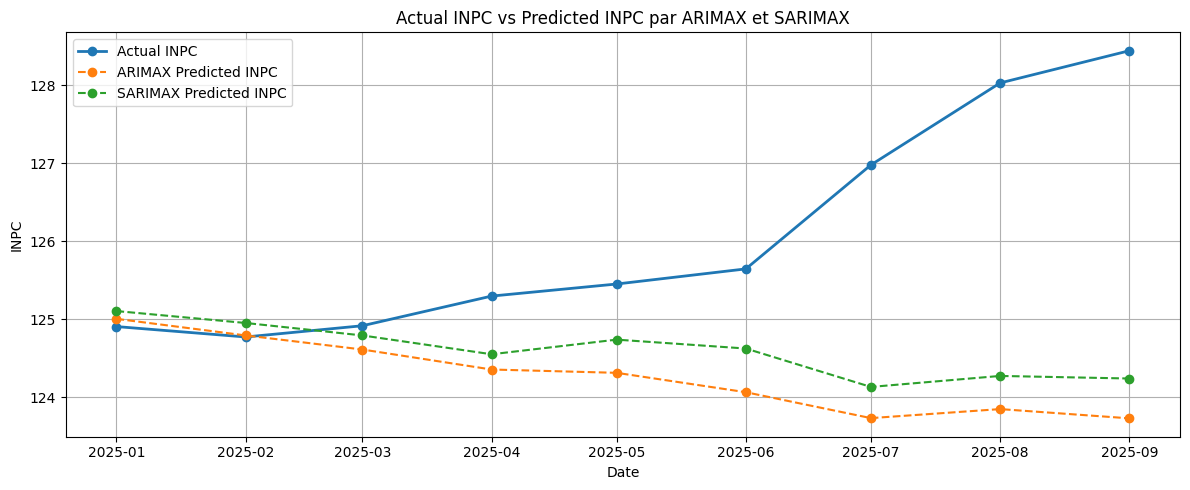

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\figures\statistical_models_inpc_forecast.png


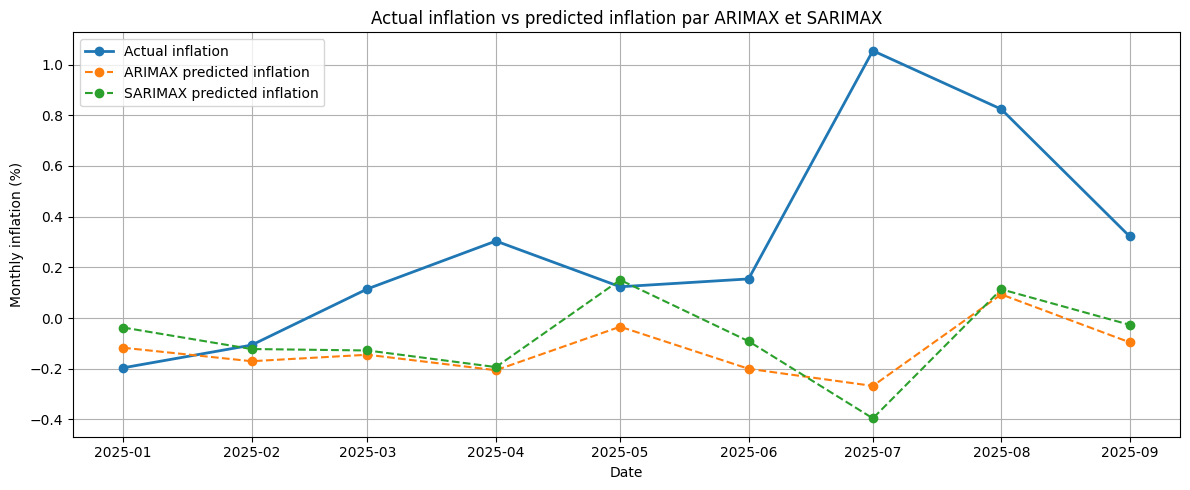

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\figures\statistical_models_inflation_forecast.png


,date,INPC_reel,inflation_reelle,ARIMAX_INPC_predit,SARIMAX_INPC_predit,ARIMAX_inflation_predite,SARIMAX_inflation_predite
0,2025-01-01,124.907260,-0.196386,125.006355,125.106121,-0.117083,-0.037306
1,2025-02-01,124.773955,-0.106780,124.793691,124.953350,-0.170267,-0.122188
2,2025-03-01,124.917772,0.115195,124.613200,124.793591,-0.144737,-0.127937
3,2025-04-01,125.297957,0.303886,124.356954,124.552424,-0.205845,-0.193439
4,2025-05-01,125.452688,0.123414,124.314470,124.739811,-0.034169,0.150335
5,2025-06-01,125.646513,0.154381,124.065875,124.625854,-0.200173,-0.091398
6,2025-07-01,126.978799,1.054762,123.734067,124.133707,-0.267803,-0.395681
7,2025-08-01,128.029590,0.824127,123.849632,124.274649,0.093354,0.113477
8,2025-09-01,128.442654,0.322113,123.731123,124.241552,-0.095734,-0.026636


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\tables\statistical_model_predictions.csv


In [13]:
# %% Cell 12
# ============================================================
# 12. Graphiques ARIMAX / SARIMAX
# ============================================================

pred_arimax = predictions_stats.get("ARIMAX_IVU_TAUX")
pred_sarimax = predictions_stats.get("SARIMAX_IVU_TAUX")

if pred_arimax is None or pred_sarimax is None:
    print("Attention : ARIMAX ou SARIMAX n'a pas été estimé. Les graphiques comparatifs ne peuvent pas être complets.")
else:
    # Graphique 1 : Actual INPC vs ARIMAX vs SARIMAX
    plt.figure(figsize=(12, 5))
    plt.plot(pred_arimax["date"], pred_arimax["INPC_reel"], marker="o", linewidth=2, label="Actual INPC")
    plt.plot(pred_arimax["date"], pred_arimax["INPC_predit"], marker="o", linestyle="--", label="ARIMAX Predicted INPC")
    plt.plot(pred_sarimax["date"], pred_sarimax["INPC_predit"], marker="o", linestyle="--", label="SARIMAX Predicted INPC")
    plt.title("Actual INPC vs Predicted INPC par ARIMAX et SARIMAX")
    plt.xlabel("Date")
    plt.ylabel("INPC")
    plt.legend()
    plt.tight_layout()
    chemin = FIGURES_DIR / "statistical_models_inpc_forecast.png"
    plt.savefig(chemin, dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", chemin)

    # Graphique 2 : Actual inflation vs ARIMAX vs SARIMAX
    plt.figure(figsize=(12, 5))
    plt.plot(pred_arimax["date"], pred_arimax["inflation_reelle"], marker="o", linewidth=2, label="Actual inflation")
    plt.plot(pred_arimax["date"], pred_arimax["inflation_predite"], marker="o", linestyle="--", label="ARIMAX predicted inflation")
    plt.plot(pred_sarimax["date"], pred_sarimax["inflation_predite"], marker="o", linestyle="--", label="SARIMAX predicted inflation")
    plt.title("Actual inflation vs predicted inflation par ARIMAX et SARIMAX")
    plt.xlabel("Date")
    plt.ylabel("Monthly inflation (%)")
    plt.legend()
    plt.tight_layout()
    chemin = FIGURES_DIR / "statistical_models_inflation_forecast.png"
    plt.savefig(chemin, dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", chemin)

    predictions_stats_compare = pred_arimax[["date", "INPC_reel", "inflation_reelle"]].copy()
    predictions_stats_compare["ARIMAX_INPC_predit"] = pred_arimax["INPC_predit"].values
    predictions_stats_compare["SARIMAX_INPC_predit"] = pred_sarimax["INPC_predit"].values
    predictions_stats_compare["ARIMAX_inflation_predite"] = pred_arimax["inflation_predite"].values
    predictions_stats_compare["SARIMAX_inflation_predite"] = pred_sarimax["inflation_predite"].values
    afficher_et_sauver(predictions_stats_compare, "statistical_model_predictions")

## 14. Machine-learning models

Estimate the original Elastic Net, Ridge, Lasso, Random Forest and Gradient Boosting models, then retain the two best models under the original selection rule.

In [14]:
# %% Cell 13
# ============================================================
# 13. Modèles Machine Learning avec IVU + taux
#     On estime plusieurs modèles, puis on garde seulement les 2 meilleurs
#     Tableau final simplifié pour la soutenance
# ============================================================

# Pour le ML, on ajoute l'inflation retardée d'un mois.
# On évite inflation_lag12 pour ne pas perdre trop d'observations avec une série courte.
#
# Dans le tableau final :
# - On garde seulement les 2 meilleurs modèles ML.
# - On supprime Accuracy car elle peut être trompeuse.
# - Pour chaque indicateur, on garde la meilleure valeur entre inflation et INPC :
#   MAE, RMSE, MAPE : plus petit = meilleur
#   R2 : plus grand = meilleur

features_ml_macro = ["inflation_lag1"] + features_macro

base_ml_macro = base_macro.dropna(
    subset=["INPC_global", "inflation_mensuelle"] + features_ml_macro
).copy()

train_ml, test_ml, y_train_ml, y_test_ml, X_train_ml, X_test_ml = split_train_test(
    base_ml_macro,
    features_ml_macro
)


# ------------------------------------------------------------
# Fonction pour garder seulement le meilleur indicateur
# ------------------------------------------------------------

def meilleure_valeur(row, col_inflation, col_inpc, sens="min"):
    val_inflation = row[col_inflation] if col_inflation in row.index else np.nan
    val_inpc = row[col_inpc] if col_inpc in row.index else np.nan

    if pd.isna(val_inflation) and pd.isna(val_inpc):
        return np.nan

    if pd.isna(val_inflation):
        return val_inpc

    if pd.isna(val_inpc):
        return val_inflation

    if sens == "min":
        return min(val_inflation, val_inpc)

    if sens == "max":
        return max(val_inflation, val_inpc)

    return np.nan


# ------------------------------------------------------------
# Modèles Machine Learning testés
# ------------------------------------------------------------

modeles_ml = {
    "Elastic_Net_IVU_TAUX": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            alphas=np.logspace(-4, 2, 80),
            cv=3,
            max_iter=10000,
            random_state=42,
        ))
    ]),

    "Ridge_IVU_TAUX": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(
            alphas=np.logspace(-4, 4, 100)
        ))
    ]),

    "Lasso_IVU_TAUX": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LassoCV(
            alphas=np.logspace(-4, 2, 80),
            cv=3,
            max_iter=10000,
            random_state=42
        ))
    ]),

    "Random_Forest_IVU_TAUX": RandomForestRegressor(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42,
    ),

    "Gradient_Boosting_IVU_TAUX": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=3,
        random_state=42,
    ),
}


resultats_ml_macro = []
predictions_ml_macro = {}


# ------------------------------------------------------------
# Estimation des modèles ML
# ------------------------------------------------------------

for nom_modele, modele in modeles_ml.items():
    try:
        print("Estimation ML :", nom_modele)

        modele.fit(X_train_ml, y_train_ml)

        pred = modele.predict(X_test_ml)

        ligne, pred_df = evaluer_prediction(
            nom_modele,
            train_ml,
            test_ml,
            y_test_ml,
            pred,
            extra={
                "nb_variables": len(features_ml_macro),
                "nb_train": len(train_ml),
                "nb_test": len(test_ml),
            }
        )

        resultats_ml_macro.append(ligne)
        predictions_ml_macro[nom_modele] = pred_df

    except Exception as e:
        print(f"Modèle {nom_modele} non estimé : {e}")


if len(resultats_ml_macro) == 0:
    raise RuntimeError("Aucun modèle Machine Learning n'a pu être estimé.")


# ============================================================
# Tableau interne détaillé non sauvegardé
# ============================================================

comparaison_ml_detail = pd.DataFrame(resultats_ml_macro)


# ============================================================
# Tableau final simplifié
# ============================================================

lignes_ml_finales = []

for _, row in comparaison_ml_detail.iterrows():

    ligne_finale = {
        "modele": row["modele"],

        # On garde la meilleure valeur entre inflation et INPC
        "MAE": meilleure_valeur(
            row,
            "MAE_inflation",
            "MAE_INPC",
            sens="min"
        ),

        "RMSE": meilleure_valeur(
            row,
            "RMSE_inflation",
            "RMSE_INPC",
            sens="min"
        ),

        "MAPE_%": meilleure_valeur(
            row,
            "MAPE_inflation_%",
            "MAPE_INPC_%",
            sens="min"
        ),

        "R2": meilleure_valeur(
            row,
            "R2_inflation",
            "R2_INPC",
            sens="max"
        ),

        "nb_train": row["nb_train"],
        "nb_test": row["nb_test"],
    }

    lignes_ml_finales.append(ligne_finale)


comparaison_ml_macro = pd.DataFrame(lignes_ml_finales)


# ------------------------------------------------------------
# On garde seulement les 2 meilleurs modèles selon RMSE retenu
# ------------------------------------------------------------

comparaison_ml_top2 = comparaison_ml_macro.sort_values(
    "RMSE"
).head(2).reset_index(drop=True)


# ------------------------------------------------------------
# Sauvegarde d'un seul tableau final
# ------------------------------------------------------------

afficher_et_sauver(
    comparaison_ml_top2,
    "ml_top2_model_comparison"
)


# ------------------------------------------------------------
# Prédictions des deux meilleurs modèles retenus
# ------------------------------------------------------------

modeles_ml_retenus = list(comparaison_ml_top2["modele"])

ml_top2_predictions = {}

for nom_modele in modeles_ml_retenus:
    if nom_modele in predictions_ml_macro:
        ml_top2_predictions[nom_modele] = predictions_ml_macro[nom_modele]


meilleur_ml_macro = comparaison_ml_top2.iloc[0]

print(
    "Meilleur modèle ML selon RMSE retenu :",
    meilleur_ml_macro["modele"]
)

print(
    "Deux modèles ML retenus :",
    modeles_ml_retenus
)

Estimation ML : Elastic_Net_IVU_TAUX
Estimation ML : Ridge_IVU_TAUX
Estimation ML : Lasso_IVU_TAUX
Estimation ML : Random_Forest_IVU_TAUX
Estimation ML : Gradient_Boosting_IVU_TAUX


,Model,MAE,RMSE,MAPE (%),R2,Training observations,Test observations
0,Gradient Boosting,0.268596,0.342975,0.573242,0.948666,56,9
1,Random Forest,0.247272,0.350638,0.365538,0.936762,56,9


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\tables\ml_top2_model_comparison.csv
Meilleur modèle ML selon RMSE retenu : Gradient_Boosting_IVU_TAUX
Deux modèles ML retenus : ['Gradient_Boosting_IVU_TAUX', 'Random_Forest_IVU_TAUX']


## 15. Top two machine-learning forecasts

Compare Gradient Boosting and Random Forest forecasts with observed values.

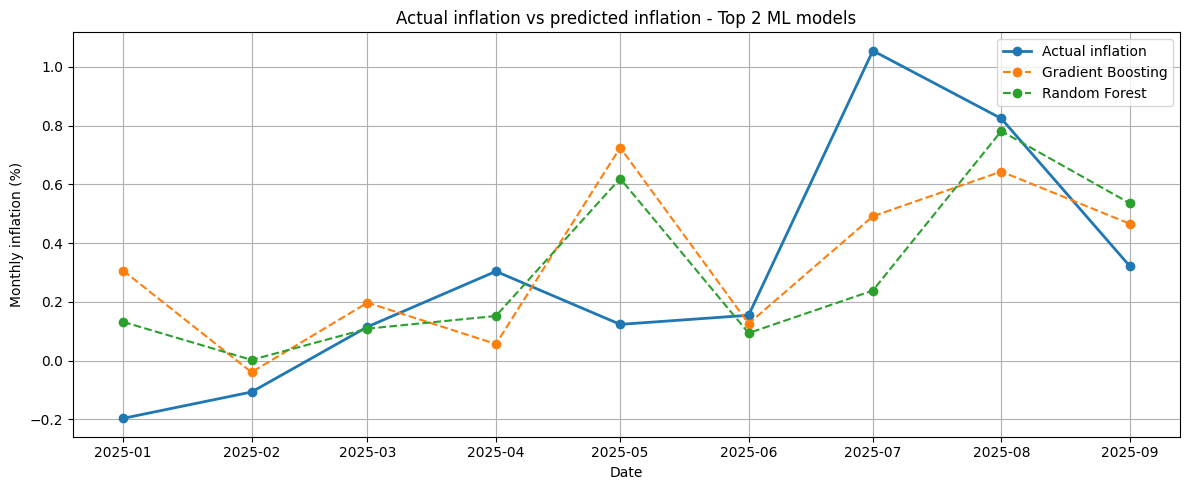

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\figures\ml_top2_inflation.png


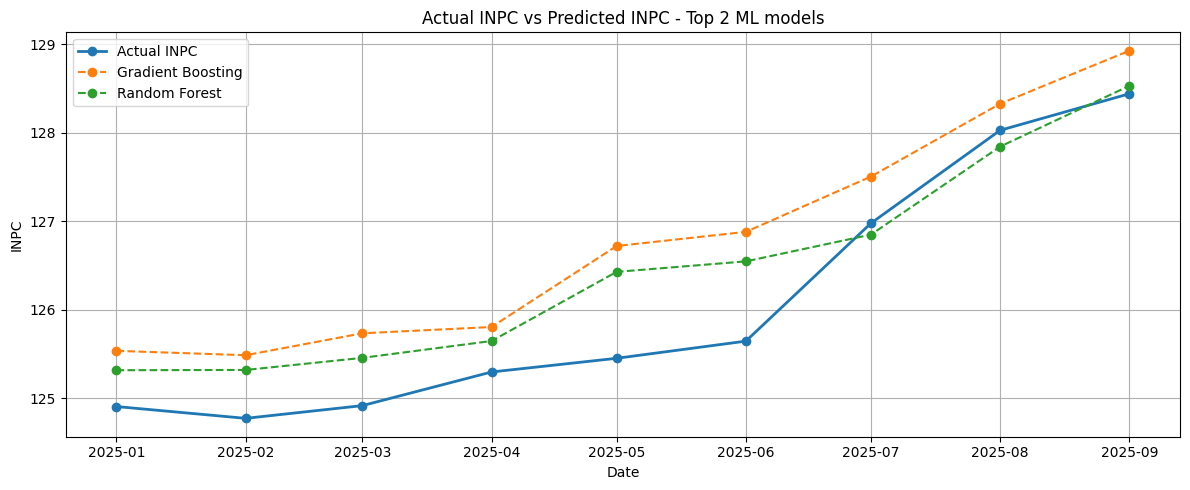

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\figures\ml_top2_inpc.png


,date,INPC_reel,inflation_reelle,Gradient_Boosting_IVU_TAUX_INPC_predit,Gradient_Boosting_IVU_TAUX_inflation_predite,Random_Forest_IVU_TAUX_INPC_predit,Random_Forest_IVU_TAUX_inflation_predite
60,2025-01-01,124.907260,-0.196386,125.536889,0.306425,125.317851,0.131792
61,2025-02-01,124.773955,-0.106780,125.487475,-0.039369,125.320950,0.002473
62,2025-03-01,124.917772,0.115195,125.735236,0.197243,125.457491,0.108894
63,2025-04-01,125.297957,0.303886,125.806374,0.056562,125.648332,0.152000
64,2025-05-01,125.452688,0.123414,126.721747,0.724970,126.429538,0.619816
65,2025-06-01,125.646513,0.154381,126.881493,0.125981,126.548117,0.093747
66,2025-07-01,126.978799,1.054762,127.506426,0.491324,126.850396,0.238580
67,2025-08-01,128.029590,0.824127,128.329686,0.643586,127.845350,0.781292
68,2025-09-01,128.442654,0.322113,128.929036,0.465951,128.532297,0.535887


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\tables\ml_top2_predictions.csv


In [15]:
# %% Cell 14
# ============================================================
# 14. Graphiques des 2 meilleurs modèles ML
# ============================================================

noms_top2_ml = comparaison_ml_top2["modele"].tolist()

# Graphique 1 : Actual inflation vs les 2 meilleurs modèles ML
plt.figure(figsize=(12, 5))
plt.plot(test_ml["date"], test_ml["inflation_mensuelle"], marker="o", linewidth=2, label="Actual inflation")

for nom_modele in noms_top2_ml:
    pred_df = predictions_ml_macro[nom_modele]
    plt.plot(pred_df["date"], pred_df["inflation_predite"], marker="o", linestyle="--", label=MODEL_LABELS_EN.get(nom_modele, nom_modele))

plt.title("Actual inflation vs predicted inflation - Top 2 ML models")
plt.xlabel("Date")
plt.ylabel("Monthly inflation (%)")
plt.legend()
plt.tight_layout()
chemin = FIGURES_DIR / "ml_top2_inflation.png"
plt.savefig(chemin, dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved:", chemin)

# Graphique 2 : Actual INPC vs les 2 meilleurs modèles ML
plt.figure(figsize=(12, 5))
plt.plot(test_ml["date"], test_ml["INPC_global"], marker="o", linewidth=2, label="Actual INPC")

for nom_modele in noms_top2_ml:
    pred_df = predictions_ml_macro[nom_modele]
    plt.plot(pred_df["date"], pred_df["INPC_predit"], marker="o", linestyle="--", label=MODEL_LABELS_EN.get(nom_modele, nom_modele))

plt.title("Actual INPC vs Predicted INPC - Top 2 ML models")
plt.xlabel("Date")
plt.ylabel("INPC")
plt.legend()
plt.tight_layout()
chemin = FIGURES_DIR / "ml_top2_inpc.png"
plt.savefig(chemin, dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved:", chemin)

# Sauvegarde des prédictions des 2 meilleurs modèles ML dans un seul fichier
ml_top2_predictions = test_ml[["date", "INPC_global", "inflation_mensuelle"]].copy()
ml_top2_predictions = ml_top2_predictions.rename(columns={
    "INPC_global": "INPC_reel",
    "inflation_mensuelle": "inflation_reelle",
})

for nom_modele in noms_top2_ml:
    pred_df = predictions_ml_macro[nom_modele].copy()
    ml_top2_predictions[f"{nom_modele}_INPC_predit"] = pred_df["INPC_predit"].values
    ml_top2_predictions[f"{nom_modele}_inflation_predite"] = pred_df["inflation_predite"].values

afficher_et_sauver(ml_top2_predictions, "ml_top2_predictions")

## 16. Final model comparison

Combine the two statistical models and the two selected machine-learning models without changing the original results.

,Model family,Model,MAE,RMSE,MAPE (%),R2,AIC,BIC,order,seasonal_order,Training observations,Test observations
0,Machine Learning,Gradient Boosting,0.268596,0.342975,0.573242,0.948666,NaN,NaN,NaN,NaN,56,9
1,Machine Learning,Random Forest,0.247272,0.350638,0.365538,0.936762,NaN,NaN,NaN,NaN,56,9
2,Statistical,ARIMAX,0.432864,0.572136,1.415961,0.745294,77.033880,98.912704,"(1, 0, 1)","(0, 0, 0, 0)",56,9
3,Statistical,SARIMAX,0.410832,0.589120,1.202471,0.744564,70.383447,91.235482,"(1, 0, 1)","(0, 0, 1, 12)",56,9


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\tables\final_model_comparison.csv


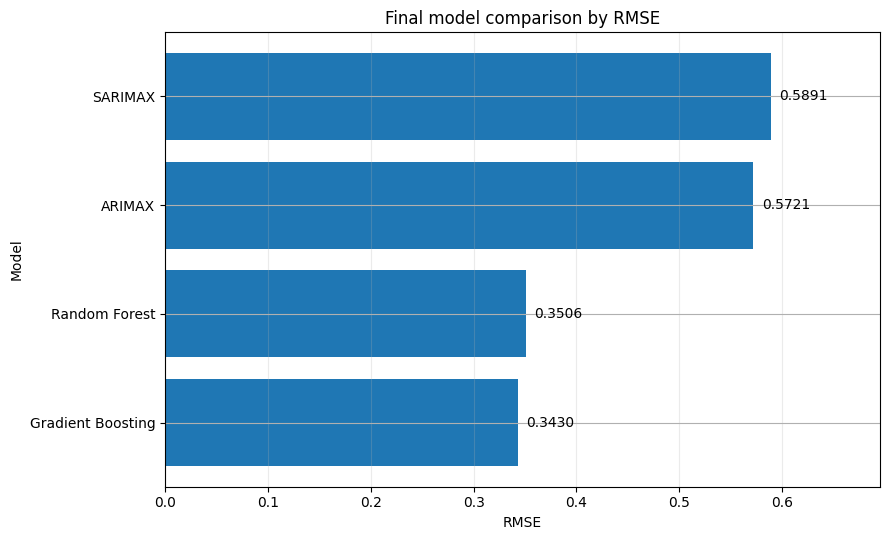

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\figures\final_model_comparison_rmse.png
Meilleur modèle global selon RMSE : Gradient_Boosting_IVU_TAUX - famille : Machine Learning


In [16]:
# %% Cell 15 
# ============================================================
# Comparaison finale :
# ARIMAX / SARIMAX + Top 2 Machine Learning
# ============================================================

# Après simplification des tableaux, la métrique finale s'appelle RMSE
# et non plus RMSE_inflation.
METRIQUE_SELECTION_FINALE = "RMSE"

# ------------------------------------------------------------
# Partie modèles statistiques : ARIMAX / SARIMAX
# ------------------------------------------------------------

stats_final = comparaison_stats_macro.copy()
stats_final["famille"] = "Statistique"

# ------------------------------------------------------------
# Partie Machine Learning : Top 2 ML models
# ------------------------------------------------------------

ml_final = comparaison_ml_top2.copy()
ml_final["famille"] = "Machine Learning"

# ------------------------------------------------------------
# Fusion des deux familles
# ------------------------------------------------------------

comparaison_finale = pd.concat(
    [stats_final, ml_final],
    ignore_index=True,
    sort=False
)

# ------------------------------------------------------------
# Colonnes finales souhaitées
# Certaines colonnes existent pour ARIMAX/SARIMAX mais pas pour ML
# donc on les crée si elles manquent
# ------------------------------------------------------------

colonnes_finales = [
    "famille",
    "modele",
    "MAE",
    "RMSE",
    "MAPE_%",
    "R2",
    "AIC",
    "BIC",
    "order",
    "seasonal_order",
    "nb_train",
    "nb_test",
]

for col in colonnes_finales:
    if col not in comparaison_finale.columns:
        comparaison_finale[col] = np.nan

# ------------------------------------------------------------
# Tri selon la métrique finale simplifiée
# ------------------------------------------------------------

comparaison_finale = comparaison_finale.sort_values(
    METRIQUE_SELECTION_FINALE
).reset_index(drop=True)

comparaison_finale = comparaison_finale[colonnes_finales]

# ------------------------------------------------------------
# Sauvegarde et affichage du tableau final unique
# Remarque : afficher_et_sauver affiche déjto le tableau.
# Donc on ne met pas display(comparaison_finale) pour éviter le doublon.
# ------------------------------------------------------------

afficher_et_sauver(
    comparaison_finale,
    "final_model_comparison"
)

# Public summary figure: final RMSE comparison
plt.figure(figsize=(9, 5.5))
comparison_plot = public_table(comparaison_finale)[["Model", "RMSE"]].dropna().sort_values("RMSE")
bars = plt.barh(comparison_plot["Model"], comparison_plot["RMSE"])
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.title("Final model comparison by RMSE")
plt.grid(axis="x", alpha=0.25)
for bar, value in zip(bars, comparison_plot["RMSE"]):
    plt.text(value + 0.008, bar.get_y() + bar.get_height() / 2, f"{value:.4f}", va="center")
plt.xlim(0, comparison_plot["RMSE"].max() * 1.18)
plt.tight_layout()
path = FIGURES_DIR / "final_model_comparison_rmse.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved:", path)

meilleur_modele_global = comparaison_finale.iloc[0]

print(
    "Meilleur modèle global selon",
    METRIQUE_SELECTION_FINALE,
    ":",
    meilleur_modele_global["modele"],
    "- famille :",
    meilleur_modele_global["famille"]
)

## 17. Methodological summary

Summarise the original methodological choices.

In [17]:
# %% Cell 16
# ============================================================
# 16. Note méthodologique finale
# ============================================================

print("Methodological summary:")
print("1) Le Top 10 Niveau2 est identifié par DLM et score économique, puis illustré par des diagrammes.")
print("2) Les modèles statistiques retenus sont uniquement ARIMAX et SARIMAX.")
print("3) Les modèles Machine Learning sont estimés, mais seuls les deux meilleurs sont gardés dans la comparaison finale.")
print("4) L'indicateur principal de sélection est", METRIQUE_SELECTION, "car le modèle prédit d'abord l'inflation mensuelle.")
print("5) Les indicateurs INPC sont conservés comme lecture complémentaire après reconstruction de l'indice.")
print("6) Le Top10 n'est pas injecté dans le ML principal pour éviter le sur-ajustement avec une série courte.")

Methodological summary:
1) Le Top 10 Niveau2 est identifié par DLM et score économique, puis illustré par des diagrammes.
2) Les modèles statistiques retenus sont uniquement ARIMAX et SARIMAX.
3) Les modèles Machine Learning sont estimés, mais seuls les deux meilleurs sont gardés dans la comparaison finale.
4) L'indicateur principal de sélection est RMSE_inflation car le modèle prédit d'abord l'inflation mensuelle.
5) Les indicateurs INPC sont conservés comme lecture complémentaire après reconstruction de l'indice.
6) Le Top10 n'est pas injecté dans le ML principal pour éviter le sur-ajustement avec une série courte.


## 18. Generated outputs

List the public summary outputs generated by the notebook.

In [18]:
# %% Cell 17
# ============================================================
# 17. Summary of generated files
# ============================================================

print("Processing completed.")
print("Figures are stored in:", FIGURES_DIR.resolve())
print("Tables are stored in:", TABLES_DIR.resolve())
print("Key generated files:")
print("- top10_level2_economic_score.csv")
print("- top10_imported_categories.csv")
print("- top10_economic_score.png")
print("- top10_cumulative_effect.png")
print("- top10_import_share.png")
print("- top10_immediate_vs_cumulative_effect.png")
print("- statistical_model_comparison.csv")
print("- statistical_model_predictions.csv")
print("- statistical_models_inpc_forecast.png")
print("- statistical_models_inflation_forecast.png")
print("- ml_top2_model_comparison.csv")
print("- ml_top2_predictions.csv")
print("- ml_top2_inflation.png")
print("- ml_top2_inpc.png")
print("- final_model_comparison.csv")
print("- final_model_comparison_rmse.png")


Processing completed.
Figures are stored in: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\figures
Tables are stored in: C:\Users\hp\Downloads\imported-inflation-mauritania-github-v3\results\tables
Key generated files:
- top10_level2_economic_score.csv
- top10_imported_categories.csv
- top10_economic_score.png
- top10_cumulative_effect.png
- top10_import_share.png
- top10_immediate_vs_cumulative_effect.png
- statistical_model_comparison.csv
- statistical_model_predictions.csv
- statistical_models_inpc_forecast.png
- statistical_models_inflation_forecast.png
- ml_top2_model_comparison.csv
- ml_top2_predictions.csv
- ml_top2_inflation.png
- ml_top2_inpc.png
- final_model_comparison.csv
- final_model_comparison_rmse.png
